In [ ]:
!pip install librosa soundfile scikit-learn matplotlib seaborn tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# ── Folder that contains ALL your .wav and .txt files ───────
DATASET_ROOT = "/content/drive/MyDrive/Button click dataset"   # ← change if needed

# ── Where to save model + normalisation params ───────────────
MODEL_SAVE_PATH = "/content/drive/MyDrive/audio_cleaner_lstm.h5"
NORM_MEAN_PATH  = "/content/drive/MyDrive/norm_mean.npy"
NORM_STD_PATH   = "/content/drive/MyDrive/norm_std.npy"

# ── Audio settings ───────────────────────────────────────────
SAMPLE_RATE    = 16000   # Hz – everything resampled to this
FRAME_DURATION = 0.025   # seconds per analysis frame  (25 ms)
HOP_DURATION   = 0.010   # seconds per hop             (10 ms)
N_MFCC         = 40      # MFCC coefficients

# ── Training settings ────────────────────────────────────────
TEST_SIZE      = 0.15
VAL_SIZE       = 0.15
BATCH_SIZE     = 32
EPOCHS         = 50
LEARNING_RATE  = 1e-3

# ── Class definitions ────────────────────────────────────────
# Must match the labels used in your .txt files (case-insensitive match applied below)
CLASSES      = ["silence", "button_click", "speech"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

# Mapping from raw label text → canonical class name
LABEL_MAP = {
    "silence":      "silence",
    "button click": "button_click",
    "button_click": "button_click",
    "speech":       "speech",
}

print("✅ Config loaded.")
print(f"   Dataset root : {DATASET_ROOT}")
print(f"   Classes      : {CLASSES}")

✅ Config loaded.
   Dataset root : /content/drive/MyDrive/Button click dataset
   Classes      : ['silence', 'button_click', 'speech']


In [ ]:
import re
from pathlib import Path

def pair_files(dataset_root):
    """
    Returns a list of (wav_path, label_path) tuples.

    Naming convention:
        WAV  : KIKF1-000-00001.wav   (last segment is zero-padded index)
        Label: Labels 1.txt          (integer index, no zero-padding)
    """
    root   = Path(dataset_root)
    pairs  = []
    errors = []

    for wav_path in sorted(root.glob("*.wav")):
        # Extract the trailing numeric index from the wav stem
        # e.g. "KIKF1-000-00001" → "00001" → 1
        match = re.search(r'-(\d+)$', wav_path.stem)
        if not match:
            errors.append(f"Cannot parse index from: {wav_path.name}")
            continue

        idx        = int(match.group(1))          # strip leading zeros → int
        label_name = f"Labels {idx}.txt"
        label_path = root / label_name

        if label_path.exists():
            pairs.append((wav_path, label_path))
        else:
            errors.append(f"Missing label file: {label_name}  (for {wav_path.name})")

    if errors:
        print("⚠️  Pairing warnings:")
        for e in errors:
            print(f"    {e}")

    print(f"✅ Paired {len(pairs)} wav+label file(s).")
    return pairs

pairs = pair_files(DATASET_ROOT)

# Quick sanity-check — show first 5 pairs
print("\nFirst 5 pairs:")
for w, l in pairs[:5]:
    print(f"  {w.name}  →  {l.name}")

✅ Paired 97 wav+label file(s).

First 5 pairs:
  KIKF1-000-00001.wav  →  Labels 1.txt
  KIKF1-000-00002.wav  →  Labels 2.txt
  KIKF1-000-00003.wav  →  Labels 3.txt
  KIKF1-000-00004.wav  →  Labels 4.txt
  KIKF1-000-00005.wav  →  Labels 5.txt


In [ ]:
def parse_label_file(label_path):
    """
    Parse a tab-separated label file.

    Returns a list of (start_sec, end_sec, class_idx) tuples.
    Rows with unrecognised labels are skipped with a warning.
    """
    segments = []
    with open(label_path, "r") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) != 3:
                print(f"  ⚠️  {label_path.name} line {lineno}: expected 3 columns, got {len(parts)} — skipping.")
                continue
            try:
                start = float(parts[0])
                end   = float(parts[1])
                raw   = parts[2].strip().lower()
                canonical = LABEL_MAP.get(raw)
                if canonical is None:
                    print(f"  ⚠️  Unknown label '{parts[2].strip()}' in {label_path.name} line {lineno} — skipping.")
                    continue
                segments.append((start, end, CLASS_TO_IDX[canonical]))
            except ValueError as e:
                print(f"  ⚠️  {label_path.name} line {lineno}: {e} — skipping.")
    return segments

# Test on first pair
print("Parsed segments for first file:")
for seg in parse_label_file(pairs[0][1]):
    start, end, idx = seg
    print(f"  {start:.3f}s – {end:.3f}s  →  {CLASSES[idx]}")

Parsed segments for first file:
  0.000s – 0.434s  →  silence
  0.434s – 0.783s  →  button_click
  0.783s – 1.492s  →  silence
  1.492s – 17.886s  →  speech
  17.886s – 18.269s  →  silence
  18.269s – 18.609s  →  button_click
  18.609s – 19.272s  →  silence


In [ ]:
import numpy as np
import librosa

def load_audio(path, sr=SAMPLE_RATE):
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y

def extract_mfcc_features(segment_audio, sr=SAMPLE_RATE):
    """
    Given a 1-D numpy audio array for ONE labelled segment,
    return a (T, N_MFCC*3) feature matrix (MFCCs + Δ + ΔΔ).
    """
    frame_len = int(sr * FRAME_DURATION)
    hop_len   = int(sr * HOP_DURATION)

    # Need at least one frame
    if len(segment_audio) < frame_len:
        segment_audio = np.pad(segment_audio, (0, frame_len - len(segment_audio)))

    mfcc   = librosa.feature.mfcc(y=segment_audio, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=frame_len, hop_length=hop_len)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features = np.concatenate([mfcc, delta, delta2], axis=0).T  # (T, F)
    return features.astype(np.float32)

print("✅ Feature extraction utilities defined.")
print(f"   Feature dimensionality: {N_MFCC * 3} per frame")

✅ Feature extraction utilities defined.
   Feature dimensionality: 120 per frame


In [ ]:
from tqdm.notebook import tqdm

MIN_SEGMENT_DURATION = 0.02   # seconds — skip segments shorter than this

X_list, y_list = [], []

for wav_path, label_path in tqdm(pairs, desc="Loading files"):
    try:
        audio    = load_audio(wav_path)
        segments = parse_label_file(label_path)
    except Exception as e:
        print(f"⚠️  Skipping {wav_path.name}: {e}")
        continue

    for (start, end, class_idx) in segments:
        duration = end - start
        if duration < MIN_SEGMENT_DURATION:
            continue

        start_sample = int(start * SAMPLE_RATE)
        end_sample   = int(end   * SAMPLE_RATE)
        seg_audio    = audio[start_sample:end_sample]

        features = extract_mfcc_features(seg_audio)   # (T, F)

        # Summarise variable-length sequence → fixed vector
        # [mean over time | std over time]  shape: (F*2,)
        feat_vec = np.concatenate([features.mean(axis=0),
                                   features.std(axis=0)])

        X_list.append(feat_vec)
        y_list.append(class_idx)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"\n✅ Dataset built: {X.shape[0]} segments")
print(f"   Feature vector shape : {X.shape[1:]}")
print(f"   Class distribution   :")
for i, cls in enumerate(CLASSES):
    count = (y == i).sum()
    print(f"     {cls:15s}: {count} ({100*count/len(y):.1f}%)")

Loading files:   0%|          | 0/97 [00:00<?, ?it/s]

  ⚠️  Labels 21.txt line 1: expected 3 columns, got 2 — skipping.

✅ Dataset built: 678 segments
   Feature vector shape : (240,)
   Class distribution   :
     silence        : 387 (57.1%)
     button_click   : 194 (28.6%)
     speech         : 97 (14.3%)


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y)

val_frac = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_frac, random_state=42, stratify=y_temp)

# Normalise using training-set statistics only (no leakage)
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0,  keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Save for inference
np.save(NORM_MEAN_PATH, mean)
np.save(NORM_STD_PATH,  std)

print(f"✅ Split — Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Reshape for LSTM: (N, timesteps=1, features)
# Each segment is represented as a single timestep of its summary vector.
# For a sequence-to-sequence LSTM see CELL 9b (optional).
X_train_lstm = X_train[:, np.newaxis, :]
X_val_lstm   = X_val[:,   np.newaxis, :]
X_test_lstm  = X_test[:,  np.newaxis, :]

print(f"   LSTM input shape     : {X_train_lstm.shape}")

✅ Split — Train: 474 | Val: 102 | Test: 102
   LSTM input shape     : (474, 1, 240)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

n_features = X_train_lstm.shape[2]
n_classes  = len(CLASSES)

def build_model(n_features, n_classes):
    inputs = layers.Input(shape=(None, n_features), name="feature_input")

    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3,
                        recurrent_dropout=0.2), name="bilstm_1")(inputs)
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False, dropout=0.3,
                        recurrent_dropout=0.2), name="bilstm_2")(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax",
                           name="class_probs")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(n_features, n_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, None, 240)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, None, 256)      │       377,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,659 (2.10 MB)

 Trainable params: 550,659 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb_list = [
    callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_accuracy",
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=8,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                 patience=4, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete. Best model saved to:", MODEL_SAVE_PATH)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8262 - loss: 0.8417
Epoch 1: val_accuracy improved from None to 0.99020, saving model to /content/drive/MyDrive/audio_cleaner_lstm.h5



Epoch 1: finished saving model to /content/drive/MyDrive/audio_cleaner_lstm.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.9409 - loss: 0.5892 - val_accuracy: 0.9902 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9979 - loss: 0.0670
Epoch 2: val_accuracy did not improve from 0.99020
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9958 - loss: 0.0439 - val_accuracy: 0.9902 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9985 - loss: 0.0080
Epoch 3: val_accuracy improved from 0.99020 to 1.00000, saving model to /content/drive/MyDrive/audio_cleaner_lstm.h5



Epoch 3: finished saving model to /content/drive/MyDrive/audio_cleaner_lstm.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9979 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9974 - loss: 0.0045
Epoch 4: val_accuracy did not improve from 1.00000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9979 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 5: val_accuracy did not improve from 1.00000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 6: val_accuracy did not improve from 1.00000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 9.2060e-04 - val_accuracy

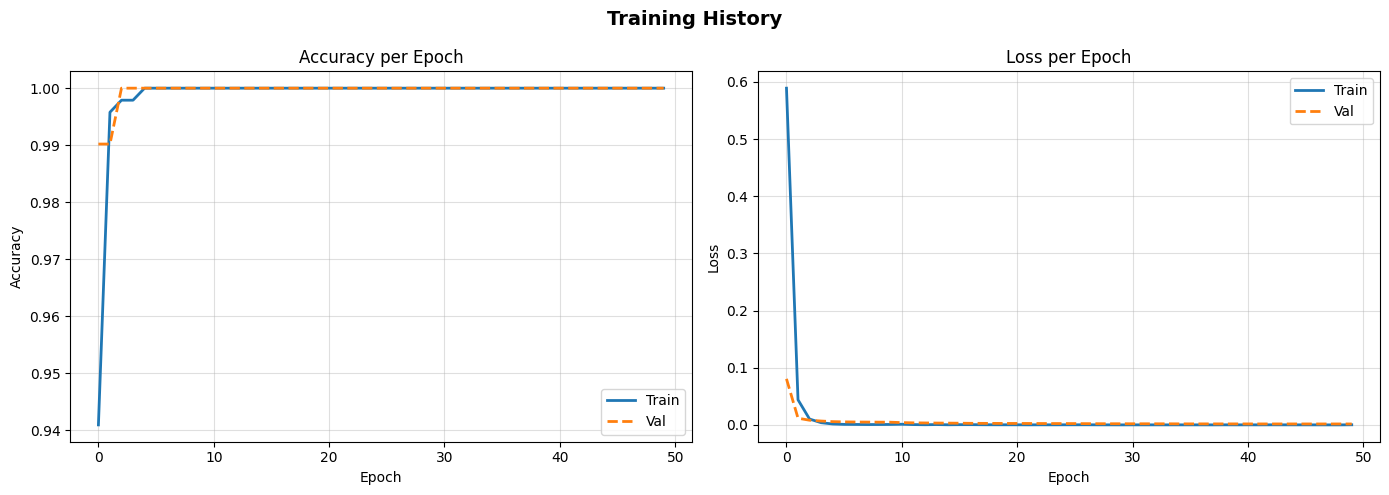

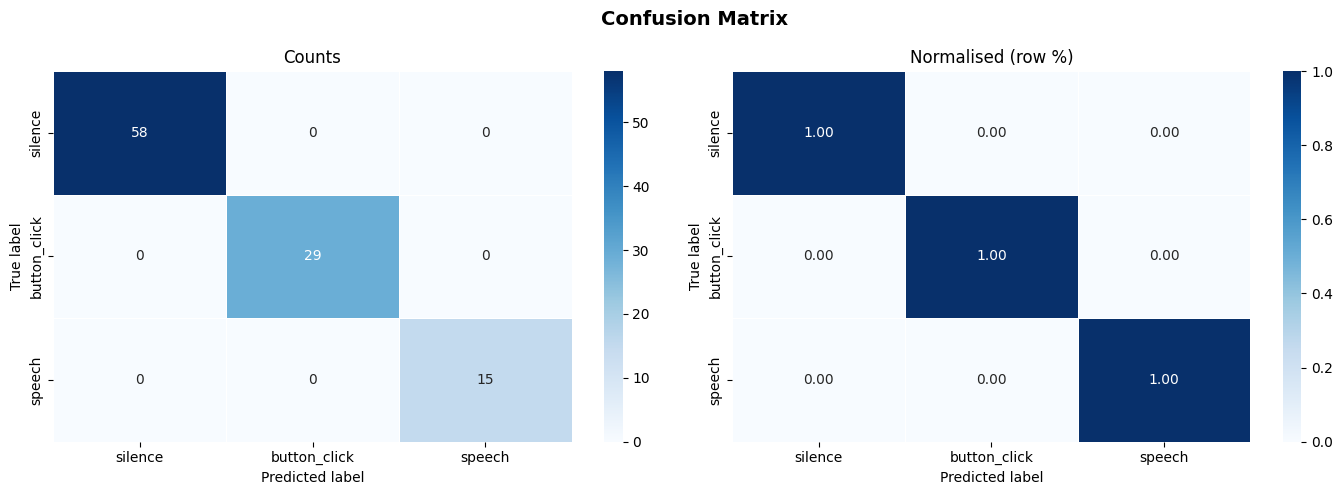

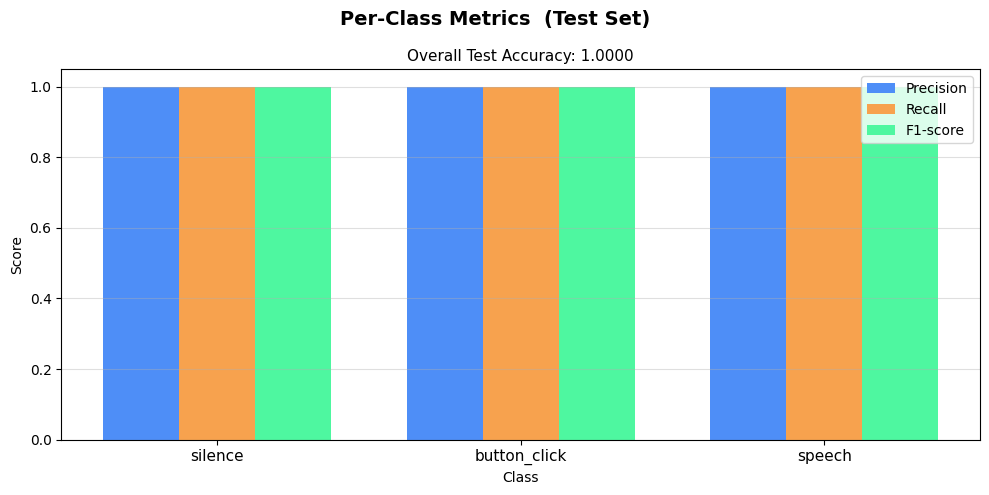


📋  Classification Report:

              precision    recall  f1-score   support

     silence       1.00      1.00      1.00        58
button_click       1.00      1.00      1.00        29
      speech       1.00      1.00      1.00        15

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



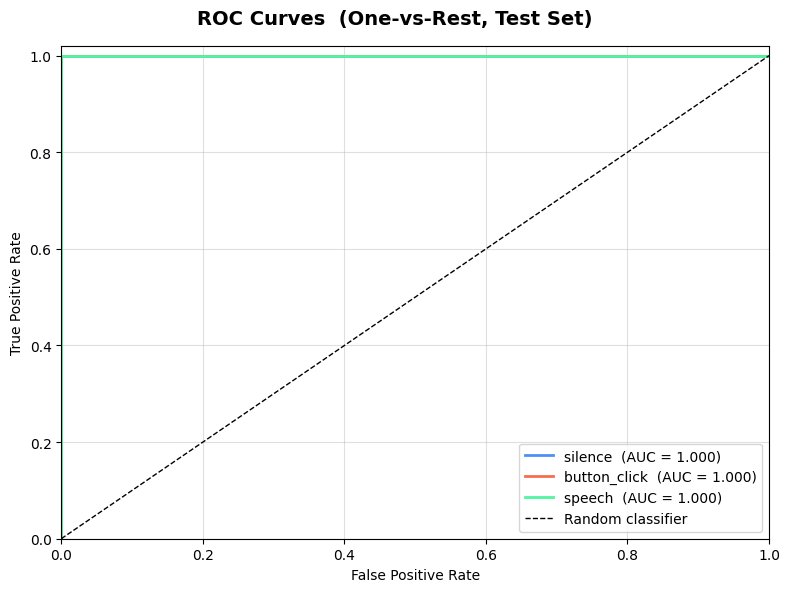

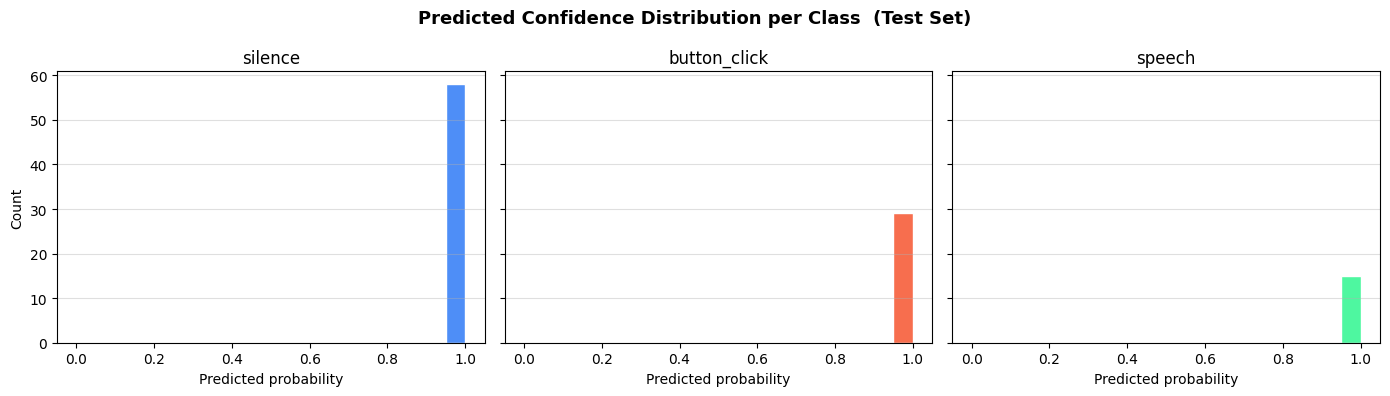

✅  All evaluation plots saved to /content/drive/MyDrive


In [ ]:
# ============================================================
# CELL — Model Evaluation Graphs
# Run this cell immediately after training.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

EVAL_SAVE_DIR = "/content/drive/MyDrive"   # folder to save plots

# ── 1. Predict on test set ───────────────────────────────────
y_probs = model.predict(X_test_lstm, verbose=0)        # (N, n_classes)
y_pred  = np.argmax(y_probs, axis=1)                   # hard labels

# ── 2. Training curves (Accuracy & Loss) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(history.history["loss"],     label="Train", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f"{EVAL_SAVE_DIR}/eval_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Confusion Matrix ──────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix", fontsize=14, fontweight="bold")

for ax, data, fmt, title in zip(
    axes,
    [cm,      cm_norm],
    ["d",     ".2f"],
    ["Counts","Normalised (row %)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax, cbar=True
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig(f"{EVAL_SAVE_DIR}/eval_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Per-class metrics bar chart ───────────────────────────
report = classification_report(
    y_test, y_pred,
    target_names=CLASSES,
    output_dict=True,
    zero_division=0
)

metrics   = ["precision", "recall", "f1-score"]
n_classes = len(CLASSES)
x         = np.arange(n_classes)
width     = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Per-Class Metrics  (Test Set)", fontsize=14, fontweight="bold")

colors = ["#4e8ef7", "#f7a24e", "#4ef7a0"]
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [report[cls][metric] for cls in CLASSES]
    ax.bar(x + i * width, vals, width, label=metric.capitalize(), color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_xlabel("Class")
ax.legend()
ax.grid(axis="y", alpha=0.4)

# Annotate accuracy on a second line
overall_acc = report["accuracy"]
ax.set_title(f"Overall Test Accuracy: {overall_acc:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig(f"{EVAL_SAVE_DIR}/eval_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Print full text report
print("\n📋  Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0))

# ── 5. ROC Curves (one-vs-rest) ──────────────────────────────
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("ROC Curves  (One-vs-Rest, Test Set)", fontsize=14, fontweight="bold")

roc_colors = ["#4e8ef7", "#f76e4e", "#4ef7a0"]
for i, (cls, color) in enumerate(zip(CLASSES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{cls}  (AUC = {roc_auc:.3f})",
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f"{EVAL_SAVE_DIR}/eval_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Confidence distribution ───────────────────────────────
fig, axes = plt.subplots(1, n_classes, figsize=(14, 4), sharey=True)
fig.suptitle("Predicted Confidence Distribution per Class  (Test Set)",
             fontsize=13, fontweight="bold")

for i, (cls, color) in enumerate(zip(CLASSES, roc_colors)):
    mask = y_test == i      # only true samples of this class
    axes[i].hist(y_probs[mask, i], bins=20, color=color,
                 edgecolor="white", range=(0, 1))
    axes[i].set_title(cls)
    axes[i].set_xlabel("Predicted probability")
    axes[i].grid(axis="y", alpha=0.4)

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{EVAL_SAVE_DIR}/eval_confidence_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅  All evaluation plots saved to", EVAL_SAVE_DIR)

📂  Select one or more .wav or .mp3 files to upload …



Saving audio 2.mp3 to audio 2.mp3

✅ Uploaded : audio 2.mp3  (90.8 KB)  [MP3]
   Running LSTM cleaner …
   Original  : 5.81s
   Cleaned   : 3.90s
   Removed   : 1.91s of silence / button clicks


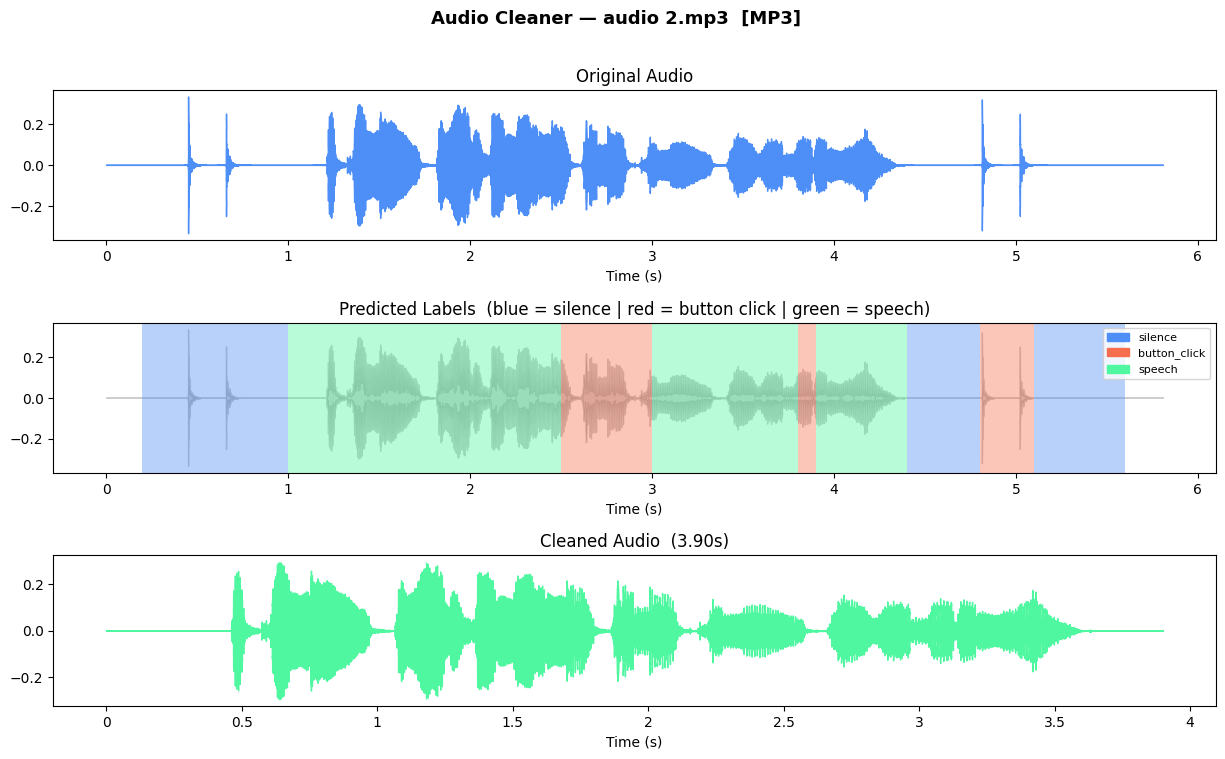


▶  Original:


▶  Cleaned:



⬇️  Downloading cleaned file: audio 2_clean.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  Done — 1 file(s) cleaned and downloaded.


In [ ]:
# ============================================================
# CELL 19 — Upload, Clean & Download Audio (WAV + MP3)
#
# Run this cell AFTER training (or after Cell 18 if reloading
# a saved model).  It will:
#   1. Pop up a file picker — accepts .wav OR .mp3 files
#   2. Run the LSTM cleaner on each uploaded file
#   3. Show a before/after waveform + label timeline
#   4. Let you play both clips inside the notebook
#   5. Auto-download the cleaned file as a .wav to your computer
# ============================================================

import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd
from pathlib import Path
from google.colab import files

# ── Paths ────────────────────────────────────────────────────
UPLOAD_DIR = "/content/uploaded_audio"
CLEAN_DIR  = "/content/cleaned_audio"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR,  exist_ok=True)

# ── Supported formats ─────────────────────────────────────────
SUPPORTED_EXTENSIONS = {".wav", ".mp3"}

# ────────────────────────────────────────────────────────────
# Helper: load audio — works for both WAV and MP3
# librosa.load() handles MP3 decoding automatically via audioread
# ────────────────────────────────────────────────────────────
def load_any_audio(path, sr=SAMPLE_RATE):
    """Load WAV or MP3 and return a mono float32 numpy array."""
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y

# ────────────────────────────────────────────────────────────
# Helper: segment-level predictor
# ────────────────────────────────────────────────────────────
def _predict_segment(seg_audio, model, mean, std, sr):
    features = extract_mfcc_features(seg_audio, sr)
    feat_vec = np.concatenate([features.mean(axis=0), features.std(axis=0)])
    feat_vec = (feat_vec - mean.squeeze()) / std.squeeze()
    inp      = feat_vec[np.newaxis, np.newaxis, :]
    probs    = model.predict(inp, verbose=0)[0]
    return int(np.argmax(probs)), probs

def _sliding_labels(audio, model, mean, std, sr,
                    window_sec=0.5, hop_sec=0.1, smooth_k=5):
    win_samples = int(window_sec * sr)
    hop_samples = int(hop_sec    * sr)
    raw, times  = [], []
    pos = 0
    while pos + win_samples <= len(audio):
        seg   = audio[pos : pos + win_samples]
        label, _ = _predict_segment(seg, model, mean, std, sr)
        raw.append(label)
        times.append((pos + win_samples / 2) / sr)
        pos += hop_samples
    # Majority-vote smoothing
    half     = smooth_k // 2
    smoothed = []
    for i in range(len(raw)):
        w = raw[max(0, i-half) : i+half+1]
        smoothed.append(max(set(w), key=w.count))
    return smoothed, times

# ────────────────────────────────────────────────────────────
# Helper: clean one file
# ────────────────────────────────────────────────────────────
IDX_SPEECH = CLASS_TO_IDX["speech"]
MARGIN_SEC = 0.05   # 50 ms grace margin kept around speech

def _clean_file(input_path, output_path, sr=SAMPLE_RATE):
    audio         = load_any_audio(input_path, sr)   # ← handles WAV & MP3
    labels, times = _sliding_labels(audio, model, mean, std, sr)
    hop_samples   = int(0.1 * sr)
    win_samples   = int(0.5 * sr)

    speech_hops = [i for i, l in enumerate(labels) if l == IDX_SPEECH]

    if not speech_hops:
        print("   ⚠️  No speech detected — saving original unchanged.")
        sf.write(output_path, audio, sr)
        return audio, audio, labels, times

    first_hop    = speech_hops[0]
    last_hop     = speech_hops[-1]
    start_sample = max(0,          first_hop * hop_samples - int(MARGIN_SEC * sr))
    end_sample   = min(len(audio), last_hop  * hop_samples + win_samples + int(MARGIN_SEC * sr))

    cleaned = audio[start_sample:end_sample]
    sf.write(output_path, cleaned, sr)   # always saves as WAV
    return audio, cleaned, labels, times

# ────────────────────────────────────────────────────────────
# Helper: colour-coded label timeline
# ────────────────────────────────────────────────────────────
LABEL_COLOURS = {
    CLASS_TO_IDX["silence"]:      "#4e8ef7",
    CLASS_TO_IDX["button_click"]: "#f76e4e",
    CLASS_TO_IDX["speech"]:       "#4ef7a0",
}

def _plot_timeline(ax, labels, times, hop_sec=0.1):
    for i, (label, t) in enumerate(zip(labels, times)):
        ax.axvspan(t - hop_sec/2, t + hop_sec/2,
                   color=LABEL_COLOURS[label], alpha=0.4, linewidth=0)
    from matplotlib.patches import Patch
    patches = [Patch(color=LABEL_COLOURS[CLASS_TO_IDX[c]], label=c)
               for c in CLASSES]
    ax.legend(handles=patches, loc="upper right", fontsize=8)

# ════════════════════════════════════════════════════════════
# MAIN — Upload → Clean → Display → Download
# ════════════════════════════════════════════════════════════

print("📂  Select one or more .wav or .mp3 files to upload …\n")
uploaded = files.upload()   # ← opens file picker

if not uploaded:
    print("No files uploaded.")
else:
    skipped = []

    for filename, file_bytes in uploaded.items():

        # ── Check extension ──────────────────────────────────
        ext = Path(filename).suffix.lower()
        if ext not in SUPPORTED_EXTENSIONS:
            print(f"⚠️  Skipping '{filename}' — unsupported format '{ext}'. "
                  f"Please upload .wav or .mp3 files only.")
            skipped.append(filename)
            continue

        # ── Save uploaded bytes ──────────────────────────────
        input_path  = os.path.join(UPLOAD_DIR, filename)
        stem        = Path(filename).stem
        output_name = f"{stem}_clean.wav"          # output is always WAV
        output_path = os.path.join(CLEAN_DIR, output_name)

        with open(input_path, "wb") as f:
            f.write(file_bytes)

        fmt_label = "MP3" if ext == ".mp3" else "WAV"
        print(f"\n✅ Uploaded : {filename}  ({len(file_bytes)/1024:.1f} KB)  [{fmt_label}]")

        # ── Run cleaner ──────────────────────────────────────
        print("   Running LSTM cleaner …")
        original, cleaned, labels, times = _clean_file(input_path, output_path)

        dur_orig    = len(original) / SAMPLE_RATE
        dur_clean   = len(cleaned)  / SAMPLE_RATE
        dur_removed = dur_orig - dur_clean
        print(f"   Original  : {dur_orig:.2f}s")
        print(f"   Cleaned   : {dur_clean:.2f}s")
        print(f"   Removed   : {dur_removed:.2f}s of silence / button clicks")

        # ── Plot ─────────────────────────────────────────────
        fig = plt.figure(figsize=(15, 8))
        fig.suptitle(f"Audio Cleaner — {filename}  [{fmt_label}]",
                     fontsize=13, fontweight="bold")
        gs  = gridspec.GridSpec(3, 1, hspace=0.55)

        ax0 = fig.add_subplot(gs[0])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax0, color="#4e8ef7")
        ax0.set_title("Original Audio")
        ax0.set_xlabel("Time (s)")

        ax1 = fig.add_subplot(gs[1])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax1,
                                 color="grey", alpha=0.4)
        _plot_timeline(ax1, labels, times)
        ax1.set_title("Predicted Labels  (blue = silence | red = button click | green = speech)")
        ax1.set_xlabel("Time (s)")

        ax2 = fig.add_subplot(gs[2])
        librosa.display.waveshow(cleaned, sr=SAMPLE_RATE, ax=ax2, color="#4ef7a0")
        ax2.set_title(f"Cleaned Audio  ({dur_clean:.2f}s)")
        ax2.set_xlabel("Time (s)")

        plt.savefig(os.path.join(CLEAN_DIR, f"{stem}_comparison.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

        # ── Audio players ────────────────────────────────────
        print("\n▶  Original:")
        ipd.display(ipd.Audio(original, rate=SAMPLE_RATE))
        print("▶  Cleaned:")
        ipd.display(ipd.Audio(cleaned,  rate=SAMPLE_RATE))

        # ── Download ─────────────────────────────────────────
        print(f"\n⬇️  Downloading cleaned file: {output_name}")
        files.download(output_path)

    # ── Summary ──────────────────────────────────────────────
    processed = len(uploaded) - len(skipped)
    print(f"\n🎉  Done — {processed} file(s) cleaned and downloaded.", end="")
    if skipped:
        print(f"  {len(skipped)} skipped: {', '.join(skipped)}", end="")
    print()

📂  Select one or more .wav or .mp3 files to upload …



Saving audio 1.wav to audio 1.wav

✅ Uploaded : audio 1.wav  (490.0 KB)  [WAV]
   Running LSTM cleaner …
   Original  : 5.69s
   Cleaned   : 5.65s
   Removed   : 0.04s of silence / button clicks


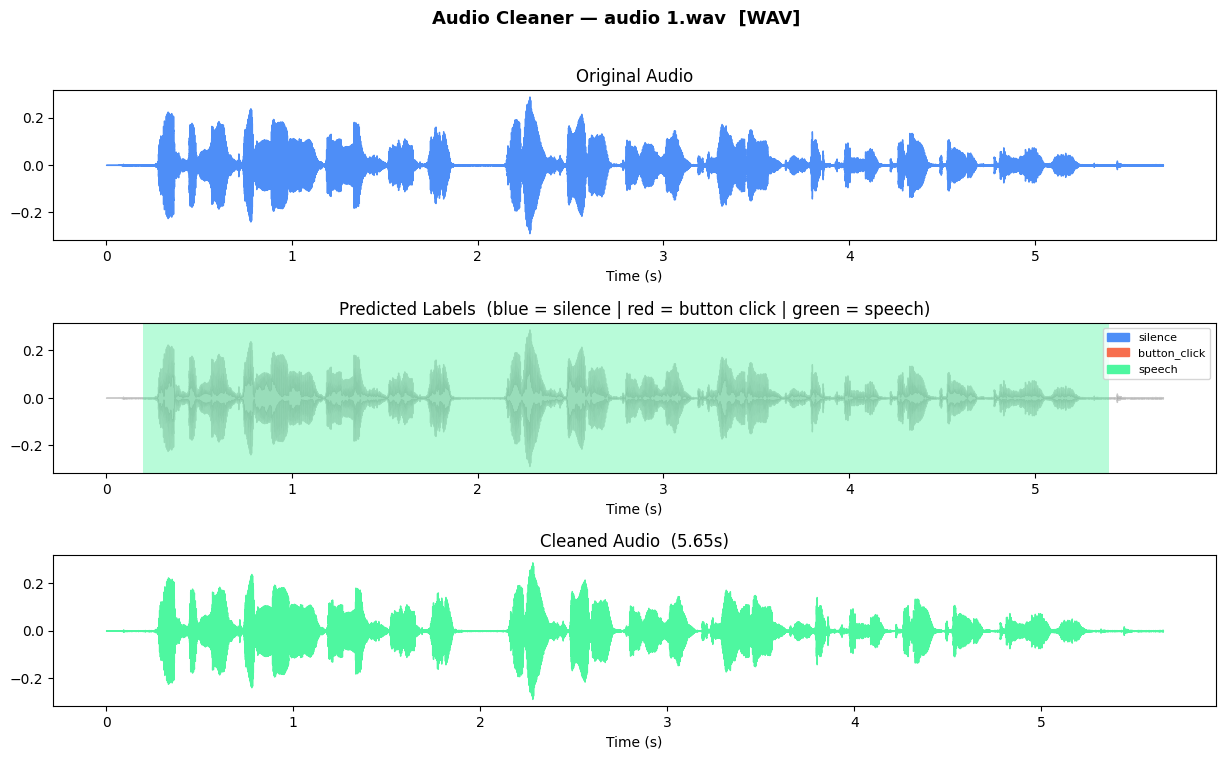


▶  Original:


▶  Cleaned:



⬇️  Downloading cleaned file: audio 1_clean.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  Done — 1 file(s) cleaned and downloaded.


In [ ]:
# ============================================================
# CELL 19 — Upload, Clean & Download Audio (WAV + MP3)
#
# Run this cell AFTER training (or after Cell 18 if reloading
# a saved model).  It will:
#   1. Pop up a file picker — accepts .wav OR .mp3 files
#   2. Run the LSTM cleaner on each uploaded file
#   3. Show a before/after waveform + label timeline
#   4. Let you play both clips inside the notebook
#   5. Auto-download the cleaned file as a .wav to your computer
# ============================================================

import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd
from pathlib import Path
from google.colab import files

# ── Paths ────────────────────────────────────────────────────
UPLOAD_DIR = "/content/uploaded_audio"
CLEAN_DIR  = "/content/cleaned_audio"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR,  exist_ok=True)

# ── Supported formats ─────────────────────────────────────────
SUPPORTED_EXTENSIONS = {".wav", ".mp3"}

# ────────────────────────────────────────────────────────────
# Helper: load audio — works for both WAV and MP3
# librosa.load() handles MP3 decoding automatically via audioread
# ────────────────────────────────────────────────────────────
def load_any_audio(path, sr=SAMPLE_RATE):
    """Load WAV or MP3 and return a mono float32 numpy array."""
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y

# ────────────────────────────────────────────────────────────
# Helper: segment-level predictor
# ────────────────────────────────────────────────────────────
def _predict_segment(seg_audio, model, mean, std, sr):
    features = extract_mfcc_features(seg_audio, sr)
    feat_vec = np.concatenate([features.mean(axis=0), features.std(axis=0)])
    feat_vec = (feat_vec - mean.squeeze()) / std.squeeze()
    inp      = feat_vec[np.newaxis, np.newaxis, :]
    probs    = model.predict(inp, verbose=0)[0]
    return int(np.argmax(probs)), probs

def _sliding_labels(audio, model, mean, std, sr,
                    window_sec=0.5, hop_sec=0.1, smooth_k=5):
    win_samples = int(window_sec * sr)
    hop_samples = int(hop_sec    * sr)
    raw, times  = [], []
    pos = 0
    while pos + win_samples <= len(audio):
        seg   = audio[pos : pos + win_samples]
        label, _ = _predict_segment(seg, model, mean, std, sr)
        raw.append(label)
        times.append((pos + win_samples / 2) / sr)
        pos += hop_samples
    # Majority-vote smoothing
    half     = smooth_k // 2
    smoothed = []
    for i in range(len(raw)):
        w = raw[max(0, i-half) : i+half+1]
        smoothed.append(max(set(w), key=w.count))
    return smoothed, times

# ────────────────────────────────────────────────────────────
# Helper: clean one file
# ────────────────────────────────────────────────────────────
IDX_SPEECH = CLASS_TO_IDX["speech"]
MARGIN_SEC = 0.05   # 50 ms grace margin kept around speech

def _clean_file(input_path, output_path, sr=SAMPLE_RATE):
    audio         = load_any_audio(input_path, sr)   # ← handles WAV & MP3
    labels, times = _sliding_labels(audio, model, mean, std, sr)
    hop_samples   = int(0.1 * sr)
    win_samples   = int(0.5 * sr)

    speech_hops = [i for i, l in enumerate(labels) if l == IDX_SPEECH]

    if not speech_hops:
        print("   ⚠️  No speech detected — saving original unchanged.")
        sf.write(output_path, audio, sr)
        return audio, audio, labels, times

    first_hop    = speech_hops[0]
    last_hop     = speech_hops[-1]
    start_sample = max(0,          first_hop * hop_samples - int(MARGIN_SEC * sr))
    end_sample   = min(len(audio), last_hop  * hop_samples + win_samples + int(MARGIN_SEC * sr))

    cleaned = audio[start_sample:end_sample]
    sf.write(output_path, cleaned, sr)   # always saves as WAV
    return audio, cleaned, labels, times

# ────────────────────────────────────────────────────────────
# Helper: colour-coded label timeline
# ────────────────────────────────────────────────────────────
LABEL_COLOURS = {
    CLASS_TO_IDX["silence"]:      "#4e8ef7",
    CLASS_TO_IDX["button_click"]: "#f76e4e",
    CLASS_TO_IDX["speech"]:       "#4ef7a0",
}

def _plot_timeline(ax, labels, times, hop_sec=0.1):
    for i, (label, t) in enumerate(zip(labels, times)):
        ax.axvspan(t - hop_sec/2, t + hop_sec/2,
                   color=LABEL_COLOURS[label], alpha=0.4, linewidth=0)
    from matplotlib.patches import Patch
    patches = [Patch(color=LABEL_COLOURS[CLASS_TO_IDX[c]], label=c)
               for c in CLASSES]
    ax.legend(handles=patches, loc="upper right", fontsize=8)

# ════════════════════════════════════════════════════════════
# MAIN — Upload → Clean → Display → Download
# ════════════════════════════════════════════════════════════

print("📂  Select one or more .wav or .mp3 files to upload …\n")
uploaded = files.upload()   # ← opens file picker

if not uploaded:
    print("No files uploaded.")
else:
    skipped = []

    for filename, file_bytes in uploaded.items():

        # ── Check extension ──────────────────────────────────
        ext = Path(filename).suffix.lower()
        if ext not in SUPPORTED_EXTENSIONS:
            print(f"⚠️  Skipping '{filename}' — unsupported format '{ext}'. "
                  f"Please upload .wav or .mp3 files only.")
            skipped.append(filename)
            continue

        # ── Save uploaded bytes ──────────────────────────────
        input_path  = os.path.join(UPLOAD_DIR, filename)
        stem        = Path(filename).stem
        output_name = f"{stem}_clean.wav"          # output is always WAV
        output_path = os.path.join(CLEAN_DIR, output_name)

        with open(input_path, "wb") as f:
            f.write(file_bytes)

        fmt_label = "MP3" if ext == ".mp3" else "WAV"
        print(f"\n✅ Uploaded : {filename}  ({len(file_bytes)/1024:.1f} KB)  [{fmt_label}]")

        # ── Run cleaner ──────────────────────────────────────
        print("   Running LSTM cleaner …")
        original, cleaned, labels, times = _clean_file(input_path, output_path)

        dur_orig    = len(original) / SAMPLE_RATE
        dur_clean   = len(cleaned)  / SAMPLE_RATE
        dur_removed = dur_orig - dur_clean
        print(f"   Original  : {dur_orig:.2f}s")
        print(f"   Cleaned   : {dur_clean:.2f}s")
        print(f"   Removed   : {dur_removed:.2f}s of silence / button clicks")

        # ── Plot ─────────────────────────────────────────────
        fig = plt.figure(figsize=(15, 8))
        fig.suptitle(f"Audio Cleaner — {filename}  [{fmt_label}]",
                     fontsize=13, fontweight="bold")
        gs  = gridspec.GridSpec(3, 1, hspace=0.55)

        ax0 = fig.add_subplot(gs[0])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax0, color="#4e8ef7")
        ax0.set_title("Original Audio")
        ax0.set_xlabel("Time (s)")

        ax1 = fig.add_subplot(gs[1])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax1,
                                 color="grey", alpha=0.4)
        _plot_timeline(ax1, labels, times)
        ax1.set_title("Predicted Labels  (blue = silence | red = button click | green = speech)")
        ax1.set_xlabel("Time (s)")

        ax2 = fig.add_subplot(gs[2])
        librosa.display.waveshow(cleaned, sr=SAMPLE_RATE, ax=ax2, color="#4ef7a0")
        ax2.set_title(f"Cleaned Audio  ({dur_clean:.2f}s)")
        ax2.set_xlabel("Time (s)")

        plt.savefig(os.path.join(CLEAN_DIR, f"{stem}_comparison.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

        # ── Audio players ────────────────────────────────────
        print("\n▶  Original:")
        ipd.display(ipd.Audio(original, rate=SAMPLE_RATE))
        print("▶  Cleaned:")
        ipd.display(ipd.Audio(cleaned,  rate=SAMPLE_RATE))

        # ── Download ─────────────────────────────────────────
        print(f"\n⬇️  Downloading cleaned file: {output_name}")
        files.download(output_path)

    # ── Summary ──────────────────────────────────────────────
    processed = len(uploaded) - len(skipped)
    print(f"\n🎉  Done — {processed} file(s) cleaned and downloaded.", end="")
    if skipped:
        print(f"  {len(skipped)} skipped: {', '.join(skipped)}", end="")
    print()

📂  Select one or more .wav or .mp3 files to upload …



Saving preview.mp3 to preview.mp3

✅ Uploaded : preview.mp3  (64.3 KB)  [MP3]
   Running LSTM cleaner …
   Original  : 1.65s
   Cleaned   : 1.65s
   Removed   : 0.00s of silence / button clicks


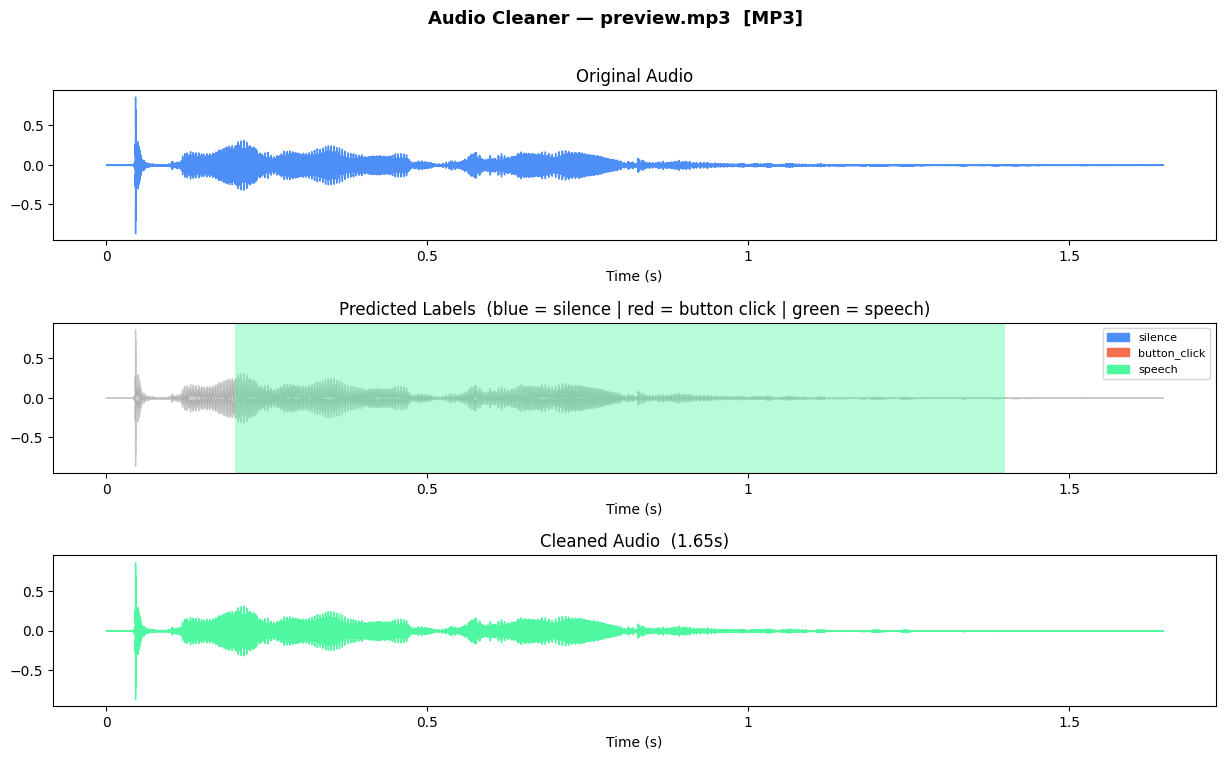


▶  Original:


▶  Cleaned:



⬇️  Downloading cleaned file: preview_clean.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  Done — 1 file(s) cleaned and downloaded.


In [ ]:
# ============================================================
# CELL 19 — Upload, Clean & Download Audio (WAV + MP3)
#
# Run this cell AFTER training (or after Cell 18 if reloading
# a saved model).  It will:
#   1. Pop up a file picker — accepts .wav OR .mp3 files
#   2. Run the LSTM cleaner on each uploaded file
#   3. Show a before/after waveform + label timeline
#   4. Let you play both clips inside the notebook
#   5. Auto-download the cleaned file as a .wav to your computer
# ============================================================

import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd
from pathlib import Path
from google.colab import files

# ── Paths ────────────────────────────────────────────────────
UPLOAD_DIR = "/content/uploaded_audio"
CLEAN_DIR  = "/content/cleaned_audio"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR,  exist_ok=True)

# ── Supported formats ─────────────────────────────────────────
SUPPORTED_EXTENSIONS = {".wav", ".mp3"}

# ────────────────────────────────────────────────────────────
# Helper: load audio — works for both WAV and MP3
# librosa.load() handles MP3 decoding automatically via audioread
# ────────────────────────────────────────────────────────────
def load_any_audio(path, sr=SAMPLE_RATE):
    """Load WAV or MP3 and return a mono float32 numpy array."""
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y

# ────────────────────────────────────────────────────────────
# Helper: segment-level predictor
# ────────────────────────────────────────────────────────────
def _predict_segment(seg_audio, model, mean, std, sr):
    features = extract_mfcc_features(seg_audio, sr)
    feat_vec = np.concatenate([features.mean(axis=0), features.std(axis=0)])
    feat_vec = (feat_vec - mean.squeeze()) / std.squeeze()
    inp      = feat_vec[np.newaxis, np.newaxis, :]
    probs    = model.predict(inp, verbose=0)[0]
    return int(np.argmax(probs)), probs

def _sliding_labels(audio, model, mean, std, sr,
                    window_sec=0.5, hop_sec=0.1, smooth_k=5):
    win_samples = int(window_sec * sr)
    hop_samples = int(hop_sec    * sr)
    raw, times  = [], []
    pos = 0
    while pos + win_samples <= len(audio):
        seg   = audio[pos : pos + win_samples]
        label, _ = _predict_segment(seg, model, mean, std, sr)
        raw.append(label)
        times.append((pos + win_samples / 2) / sr)
        pos += hop_samples
    # Majority-vote smoothing
    half     = smooth_k // 2
    smoothed = []
    for i in range(len(raw)):
        w = raw[max(0, i-half) : i+half+1]
        smoothed.append(max(set(w), key=w.count))
    return smoothed, times

# ────────────────────────────────────────────────────────────
# Helper: clean one file
# ────────────────────────────────────────────────────────────
IDX_SPEECH = CLASS_TO_IDX["speech"]
MARGIN_SEC = 0.05   # 50 ms grace margin kept around speech

def _clean_file(input_path, output_path, sr=SAMPLE_RATE):
    audio         = load_any_audio(input_path, sr)   # ← handles WAV & MP3
    labels, times = _sliding_labels(audio, model, mean, std, sr)
    hop_samples   = int(0.1 * sr)
    win_samples   = int(0.5 * sr)

    speech_hops = [i for i, l in enumerate(labels) if l == IDX_SPEECH]

    if not speech_hops:
        print("   ⚠️  No speech detected — saving original unchanged.")
        sf.write(output_path, audio, sr)
        return audio, audio, labels, times

    first_hop    = speech_hops[0]
    last_hop     = speech_hops[-1]
    start_sample = max(0,          first_hop * hop_samples - int(MARGIN_SEC * sr))
    end_sample   = min(len(audio), last_hop  * hop_samples + win_samples + int(MARGIN_SEC * sr))

    cleaned = audio[start_sample:end_sample]
    sf.write(output_path, cleaned, sr)   # always saves as WAV
    return audio, cleaned, labels, times

# ────────────────────────────────────────────────────────────
# Helper: colour-coded label timeline
# ────────────────────────────────────────────────────────────
LABEL_COLOURS = {
    CLASS_TO_IDX["silence"]:      "#4e8ef7",
    CLASS_TO_IDX["button_click"]: "#f76e4e",
    CLASS_TO_IDX["speech"]:       "#4ef7a0",
}

def _plot_timeline(ax, labels, times, hop_sec=0.1):
    for i, (label, t) in enumerate(zip(labels, times)):
        ax.axvspan(t - hop_sec/2, t + hop_sec/2,
                   color=LABEL_COLOURS[label], alpha=0.4, linewidth=0)
    from matplotlib.patches import Patch
    patches = [Patch(color=LABEL_COLOURS[CLASS_TO_IDX[c]], label=c)
               for c in CLASSES]
    ax.legend(handles=patches, loc="upper right", fontsize=8)

# ════════════════════════════════════════════════════════════
# MAIN — Upload → Clean → Display → Download
# ════════════════════════════════════════════════════════════

print("📂  Select one or more .wav or .mp3 files to upload …\n")
uploaded = files.upload()   # ← opens file picker

if not uploaded:
    print("No files uploaded.")
else:
    skipped = []

    for filename, file_bytes in uploaded.items():

        # ── Check extension ──────────────────────────────────
        ext = Path(filename).suffix.lower()
        if ext not in SUPPORTED_EXTENSIONS:
            print(f"⚠️  Skipping '{filename}' — unsupported format '{ext}'. "
                  f"Please upload .wav or .mp3 files only.")
            skipped.append(filename)
            continue

        # ── Save uploaded bytes ──────────────────────────────
        input_path  = os.path.join(UPLOAD_DIR, filename)
        stem        = Path(filename).stem
        output_name = f"{stem}_clean.wav"          # output is always WAV
        output_path = os.path.join(CLEAN_DIR, output_name)

        with open(input_path, "wb") as f:
            f.write(file_bytes)

        fmt_label = "MP3" if ext == ".mp3" else "WAV"
        print(f"\n✅ Uploaded : {filename}  ({len(file_bytes)/1024:.1f} KB)  [{fmt_label}]")

        # ── Run cleaner ──────────────────────────────────────
        print("   Running LSTM cleaner …")
        original, cleaned, labels, times = _clean_file(input_path, output_path)

        dur_orig    = len(original) / SAMPLE_RATE
        dur_clean   = len(cleaned)  / SAMPLE_RATE
        dur_removed = dur_orig - dur_clean
        print(f"   Original  : {dur_orig:.2f}s")
        print(f"   Cleaned   : {dur_clean:.2f}s")
        print(f"   Removed   : {dur_removed:.2f}s of silence / button clicks")

        # ── Plot ─────────────────────────────────────────────
        fig = plt.figure(figsize=(15, 8))
        fig.suptitle(f"Audio Cleaner — {filename}  [{fmt_label}]",
                     fontsize=13, fontweight="bold")
        gs  = gridspec.GridSpec(3, 1, hspace=0.55)

        ax0 = fig.add_subplot(gs[0])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax0, color="#4e8ef7")
        ax0.set_title("Original Audio")
        ax0.set_xlabel("Time (s)")

        ax1 = fig.add_subplot(gs[1])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax1,
                                 color="grey", alpha=0.4)
        _plot_timeline(ax1, labels, times)
        ax1.set_title("Predicted Labels  (blue = silence | red = button click | green = speech)")
        ax1.set_xlabel("Time (s)")

        ax2 = fig.add_subplot(gs[2])
        librosa.display.waveshow(cleaned, sr=SAMPLE_RATE, ax=ax2, color="#4ef7a0")
        ax2.set_title(f"Cleaned Audio  ({dur_clean:.2f}s)")
        ax2.set_xlabel("Time (s)")

        plt.savefig(os.path.join(CLEAN_DIR, f"{stem}_comparison.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

        # ── Audio players ────────────────────────────────────
        print("\n▶  Original:")
        ipd.display(ipd.Audio(original, rate=SAMPLE_RATE))
        print("▶  Cleaned:")
        ipd.display(ipd.Audio(cleaned,  rate=SAMPLE_RATE))

        # ── Download ─────────────────────────────────────────
        print(f"\n⬇️  Downloading cleaned file: {output_name}")
        files.download(output_path)

    # ── Summary ──────────────────────────────────────────────
    processed = len(uploaded) - len(skipped)
    print(f"\n🎉  Done — {processed} file(s) cleaned and downloaded.", end="")
    if skipped:
        print(f"  {len(skipped)} skipped: {', '.join(skipped)}", end="")
    print()

📂  Select one or more .wav or .mp3 files to upload …



Saving audio 5.mp3 to audio 5.mp3

✅ Uploaded : audio 5.mp3  (154.7 KB)  [MP3]
   Running LSTM cleaner …
   Original  : 9.89s
   Cleaned   : 6.20s
   Removed   : 3.69s of silence / button clicks


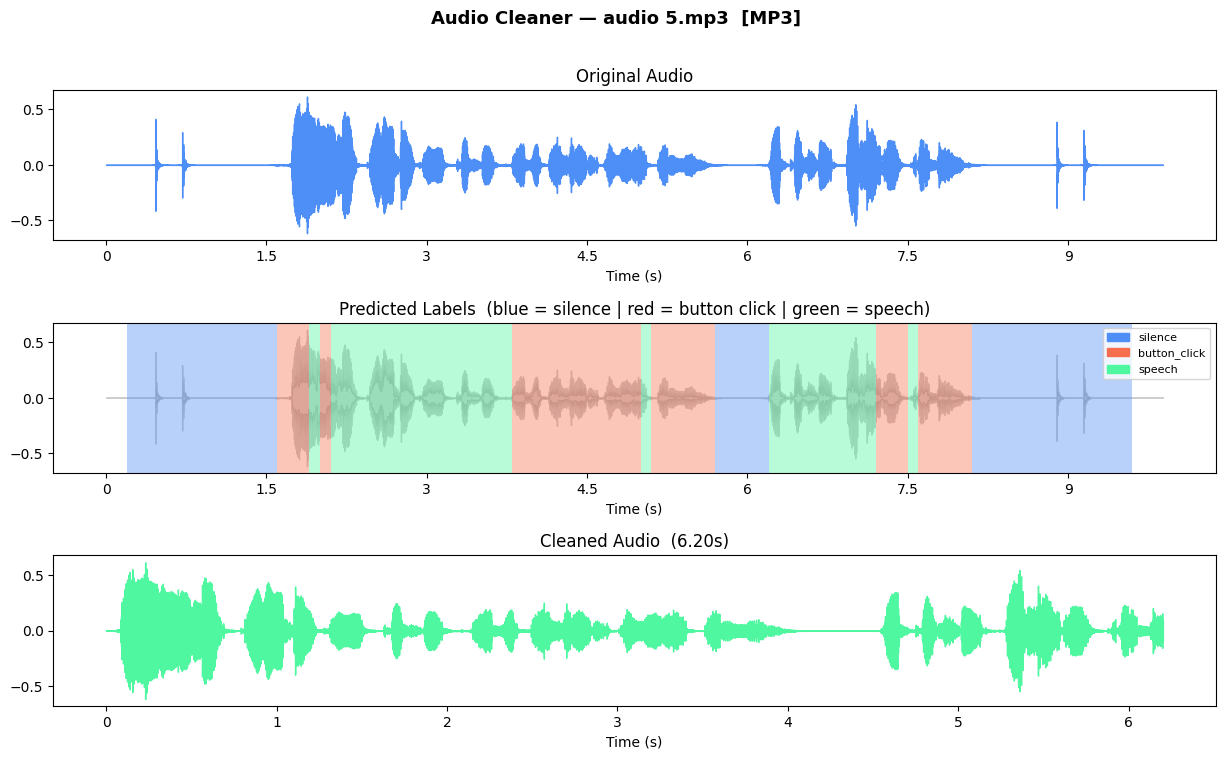


▶  Original:


▶  Cleaned:



⬇️  Downloading cleaned file: audio 5_clean.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  Done — 1 file(s) cleaned and downloaded.


In [ ]:
# ============================================================
# CELL 19 — Upload, Clean & Download Audio (WAV + MP3)
#
# Run this cell AFTER training (or after Cell 18 if reloading
# a saved model).  It will:
#   1. Pop up a file picker — accepts .wav OR .mp3 files
#   2. Run the LSTM cleaner on each uploaded file
#   3. Show a before/after waveform + label timeline
#   4. Let you play both clips inside the notebook
#   5. Auto-download the cleaned file as a .wav to your computer
# ============================================================

import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd
from pathlib import Path
from google.colab import files

# ── Paths ────────────────────────────────────────────────────
UPLOAD_DIR = "/content/uploaded_audio"
CLEAN_DIR  = "/content/cleaned_audio"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR,  exist_ok=True)

# ── Supported formats ─────────────────────────────────────────
SUPPORTED_EXTENSIONS = {".wav", ".mp3"}

# ────────────────────────────────────────────────────────────
# Helper: load audio — works for both WAV and MP3
# librosa.load() handles MP3 decoding automatically via audioread
# ────────────────────────────────────────────────────────────
def load_any_audio(path, sr=SAMPLE_RATE):
    """Load WAV or MP3 and return a mono float32 numpy array."""
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y

# ────────────────────────────────────────────────────────────
# Helper: segment-level predictor
# ────────────────────────────────────────────────────────────
def _predict_segment(seg_audio, model, mean, std, sr):
    features = extract_mfcc_features(seg_audio, sr)
    feat_vec = np.concatenate([features.mean(axis=0), features.std(axis=0)])
    feat_vec = (feat_vec - mean.squeeze()) / std.squeeze()
    inp      = feat_vec[np.newaxis, np.newaxis, :]
    probs    = model.predict(inp, verbose=0)[0]
    return int(np.argmax(probs)), probs

def _sliding_labels(audio, model, mean, std, sr,
                    window_sec=0.5, hop_sec=0.1, smooth_k=5):
    win_samples = int(window_sec * sr)
    hop_samples = int(hop_sec    * sr)
    raw, times  = [], []
    pos = 0
    while pos + win_samples <= len(audio):
        seg   = audio[pos : pos + win_samples]
        label, _ = _predict_segment(seg, model, mean, std, sr)
        raw.append(label)
        times.append((pos + win_samples / 2) / sr)
        pos += hop_samples
    # Majority-vote smoothing
    half     = smooth_k // 2
    smoothed = []
    for i in range(len(raw)):
        w = raw[max(0, i-half) : i+half+1]
        smoothed.append(max(set(w), key=w.count))
    return smoothed, times

# ────────────────────────────────────────────────────────────
# Helper: clean one file
# ────────────────────────────────────────────────────────────
IDX_SPEECH = CLASS_TO_IDX["speech"]
MARGIN_SEC = 0.05   # 50 ms grace margin kept around speech

def _clean_file(input_path, output_path, sr=SAMPLE_RATE):
    audio         = load_any_audio(input_path, sr)   # ← handles WAV & MP3
    labels, times = _sliding_labels(audio, model, mean, std, sr)
    hop_samples   = int(0.1 * sr)
    win_samples   = int(0.5 * sr)

    speech_hops = [i for i, l in enumerate(labels) if l == IDX_SPEECH]

    if not speech_hops:
        print("   ⚠️  No speech detected — saving original unchanged.")
        sf.write(output_path, audio, sr)
        return audio, audio, labels, times

    first_hop    = speech_hops[0]
    last_hop     = speech_hops[-1]
    start_sample = max(0,          first_hop * hop_samples - int(MARGIN_SEC * sr))
    end_sample   = min(len(audio), last_hop  * hop_samples + win_samples + int(MARGIN_SEC * sr))

    cleaned = audio[start_sample:end_sample]
    sf.write(output_path, cleaned, sr)   # always saves as WAV
    return audio, cleaned, labels, times

# ────────────────────────────────────────────────────────────
# Helper: colour-coded label timeline
# ────────────────────────────────────────────────────────────
LABEL_COLOURS = {
    CLASS_TO_IDX["silence"]:      "#4e8ef7",
    CLASS_TO_IDX["button_click"]: "#f76e4e",
    CLASS_TO_IDX["speech"]:       "#4ef7a0",
}

def _plot_timeline(ax, labels, times, hop_sec=0.1):
    for i, (label, t) in enumerate(zip(labels, times)):
        ax.axvspan(t - hop_sec/2, t + hop_sec/2,
                   color=LABEL_COLOURS[label], alpha=0.4, linewidth=0)
    from matplotlib.patches import Patch
    patches = [Patch(color=LABEL_COLOURS[CLASS_TO_IDX[c]], label=c)
               for c in CLASSES]
    ax.legend(handles=patches, loc="upper right", fontsize=8)

# ════════════════════════════════════════════════════════════
# MAIN — Upload → Clean → Display → Download
# ════════════════════════════════════════════════════════════

print("📂  Select one or more .wav or .mp3 files to upload …\n")
uploaded = files.upload()   # ← opens file picker

if not uploaded:
    print("No files uploaded.")
else:
    skipped = []

    for filename, file_bytes in uploaded.items():

        # ── Check extension ──────────────────────────────────
        ext = Path(filename).suffix.lower()
        if ext not in SUPPORTED_EXTENSIONS:
            print(f"⚠️  Skipping '{filename}' — unsupported format '{ext}'. "
                  f"Please upload .wav or .mp3 files only.")
            skipped.append(filename)
            continue

        # ── Save uploaded bytes ──────────────────────────────
        input_path  = os.path.join(UPLOAD_DIR, filename)
        stem        = Path(filename).stem
        output_name = f"{stem}_clean.wav"          # output is always WAV
        output_path = os.path.join(CLEAN_DIR, output_name)

        with open(input_path, "wb") as f:
            f.write(file_bytes)

        fmt_label = "MP3" if ext == ".mp3" else "WAV"
        print(f"\n✅ Uploaded : {filename}  ({len(file_bytes)/1024:.1f} KB)  [{fmt_label}]")

        # ── Run cleaner ──────────────────────────────────────
        print("   Running LSTM cleaner …")
        original, cleaned, labels, times = _clean_file(input_path, output_path)

        dur_orig    = len(original) / SAMPLE_RATE
        dur_clean   = len(cleaned)  / SAMPLE_RATE
        dur_removed = dur_orig - dur_clean
        print(f"   Original  : {dur_orig:.2f}s")
        print(f"   Cleaned   : {dur_clean:.2f}s")
        print(f"   Removed   : {dur_removed:.2f}s of silence / button clicks")

        # ── Plot ─────────────────────────────────────────────
        fig = plt.figure(figsize=(15, 8))
        fig.suptitle(f"Audio Cleaner — {filename}  [{fmt_label}]",
                     fontsize=13, fontweight="bold")
        gs  = gridspec.GridSpec(3, 1, hspace=0.55)

        ax0 = fig.add_subplot(gs[0])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax0, color="#4e8ef7")
        ax0.set_title("Original Audio")
        ax0.set_xlabel("Time (s)")

        ax1 = fig.add_subplot(gs[1])
        librosa.display.waveshow(original, sr=SAMPLE_RATE, ax=ax1,
                                 color="grey", alpha=0.4)
        _plot_timeline(ax1, labels, times)
        ax1.set_title("Predicted Labels  (blue = silence | red = button click | green = speech)")
        ax1.set_xlabel("Time (s)")

        ax2 = fig.add_subplot(gs[2])
        librosa.display.waveshow(cleaned, sr=SAMPLE_RATE, ax=ax2, color="#4ef7a0")
        ax2.set_title(f"Cleaned Audio  ({dur_clean:.2f}s)")
        ax2.set_xlabel("Time (s)")

        plt.savefig(os.path.join(CLEAN_DIR, f"{stem}_comparison.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

        # ── Audio players ────────────────────────────────────
        print("\n▶  Original:")
        ipd.display(ipd.Audio(original, rate=SAMPLE_RATE))
        print("▶  Cleaned:")
        ipd.display(ipd.Audio(cleaned,  rate=SAMPLE_RATE))

        # ── Download ─────────────────────────────────────────
        print(f"\n⬇️  Downloading cleaned file: {output_name}")
        files.download(output_path)

    # ── Summary ──────────────────────────────────────────────
    processed = len(uploaded) - len(skipped)
    print(f"\n🎉  Done — {processed} file(s) cleaned and downloaded.", end="")
    if skipped:
        print(f"  {len(skipped)} skipped: {', '.join(skipped)}", end="")
    print()